In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import importlib
import sys
import os
sns.set_theme(style="whitegrid", context="talk")
from energy_option_pricer_forward_hedge import ElectricitySpotAsianPricer
sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2
    
from dask.distributed import Client
zclient = Client("tcp://131.169.114.219:8786")
#client = Client("tcp://192.168.178.33:8786")

## Model Overview

The model used for option pricing is based on Merton's jump-diffusion:

$$
dF_t = \kappa(\theta(t) - F_t)\,dt + \sigma_t F_t\, dW_t + JdN_t
$$

with stochastic volatility:

$$
d\sigma_t = a(b - \sigma_t)\,dt + \eta\, dZ_t
$$

and correlated Brownian motions:

$$
\mathrm{corr}(W_t, Z_t) = \rho
$$

Jumps are modeled with a Poisson arrival process, and jump size is sampled from an empirical positive-jump distribution:

$$
dN_t \sim Poisson(\lambda dt), J \sim Norm(\mu_j, \sigma_j^2)
$$

The option payoff is modeled as:

$$
\max\left(\frac{1}{N}\sum_{i=1}^{N} S_{t_i} - K, 0\right)
$$

as for an **Asian-style contract on average spot**, specifically for delivery-window products in power markets.

In [2]:
pricer = ElectricitySpotAsianPricer(seed=42)


# Load data
hourly = pricer.load_hourly_csv(
    "germany_hourly_prices.csv",
    country_iso="DEU",
    timezone_col_priority=("Datetime (Local)", "Datetime (UTC)")
)

daily = pricer.aggregate_hourly_to_daily()
print(daily.head())

# Calibrate
cal = pricer.calibrate(regime="all", use_hourly=True, verbose=10)
print(pd.DataFrame([cal.__dict__]))

# Price the option
K = 80.0
T = 0.25

price_out = pricer.price_asian_call_cv_mc(
    K=K,
    T=T,
    regime="all",
    use_hourly=True,
    n_paths=12000,
    n_steps=365,
    antithetic=True,
    n_jobs=-1,
    verbose=10,
    sampling="mc",
    control_variate="average",
)
print(pd.DataFrame([price_out]))

# Greeks
greeks = pricer.finite_difference_greeks(
    K=K,
    T=T,
    regime="all",
    use_hourly=True,
    n_paths=4000,
    n_steps=365,
    antithetic=True,
    n_jobs=5,
    mc_n_jobs=1,
    verbose=10,
)
print(pd.DataFrame([greeks]))

                Price
Date                 
2015-01-01  22.340000
2015-01-02  22.340000
2015-01-03  22.340000
2015-01-04  22.340000
2015-01-05  35.857083
[CAL] started | regime=all
[CAL] finished | kappa=20.3342 | sigma0=397.7461 | z_cut=4.793 | jump_count=1167
  regime  theta_mean      kappa    sigma0   sigma_bar         a       eta  \
0    all   73.398104  20.334246  397.7461  582.034515  0.764461  0.514553   

        rho  jump_lambda    jump_mu  ...  jump_threshold_z  jump_count  \
0 -0.019876    56.181936  55.072955  ...          4.793262        1167   

   obs_frequency_years  obs_per_day  obs_per_year  spot_bump_scale  \
0             0.000114         24.0        8766.0             3.52   

   sigma_bump_scale    jump_cap  sigma_floor  sigma_ceiling  
0         19.887305  236.553319    303.69494    4022.972746  

[1 rows x 25 columns]
[PRICE-CV] started | regime=all | T=0.25 | paths=12000 | steps=365 | sampling=mc | jobs=12
[PRICE-CV] Monte Carlo / Sobol engine running


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


[PRICE-CV] finished | price=18.722272 | stderr=0.121111 | beta=0.5984
       price    stderr  discount_factor      beta  cv_expect sampling  \
0  18.722272  0.121111              1.0  0.598428  70.567917       mc   

  control_variate  n_paths  
0         average    24000  
[GREEKS] started | regime=all | T=0.25 | jobs=5
[GREEKS] pricing base / bumps


[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    4.7s
[Parallel(n_jobs=12)]: Done   3 out of  12 | elapsed:    4.7s remaining:   14.2s
[Parallel(n_jobs=12)]: Done   5 out of  12 | elapsed:    4.8s remaining:    6.7s
[Parallel(n_jobs=12)]: Done   7 out of  12 | elapsed:    4.8s remaining:    3.4s
[Parallel(n_jobs=12)]: Done   9 out of  12 | elapsed:    4.8s remaining:    1.6s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    4.9s finished
[Parallel(n_jobs=5)]: Using backend ThreadingBackend with 5 concurrent workers.


[GREEKS] finished | price=18.290652 | delta=0.085489 | vega=0.018117
       price     delta      vega    dS         dV
0  18.290652  0.085489  0.018117  3.52  19.887305


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:    1.1s remaining:    1.6s
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:    1.1s remaining:    0.7s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:    1.1s finished


In [6]:
conv = pricer.convergence_test(K=80, T=0.05, target_rel_stderr=0.01, pilot_paths=256) # to determine the optimal n_inner_paths for hedging, where option pricing happens
conv["recommended_n_paths"] 

[CONV] pilot run | n=256 | target_rel_stderr=0.010
[CONV] pilot_price=28.3301 | pilot_stderr=0.9565 | target_stderr=0.2833 | recommended_n=2919
[CONV] final_price=26.6818 | final_stderr=0.2855 | rel_stderr=0.0107 | converged=True


2919

In [3]:
stress = pricer.stress_test_table(
    K=80.0, T=0.25, regime="all", use_hourly=True,
    n_paths=12000, n_steps=365, antithetic=True,
    seed=42, n_jobs=1, verbose=10,
)

print(stress)

    SpotShockPct  VolScale  ShockedSpot  ShockedSigma0      Price    StdErr  \
0          -0.50       0.5        46.62      198.87305  13.661383  0.117869   
1          -0.50       1.0        46.62      397.74610  14.974404  0.123422   
2          -0.50       1.5        46.62      596.61915  19.114352  0.141781   
3          -0.50       2.0        46.62      795.49220  23.402023  0.164133   
4          -0.25       0.5        69.93      198.87305  15.440073  0.115942   
5          -0.25       1.0        69.93      397.74610  16.769790  0.122461   
6          -0.25       1.5        69.93      596.61915  20.920240  0.141647   
7          -0.25       2.0        69.93      795.49220  25.279401  0.163539   
8           0.00       0.5        93.24      198.87305  17.412645  0.115125   
9           0.00       1.0        93.24      397.74610  18.521453  0.121519   
10          0.00       1.5        93.24      596.61915  22.318964  0.139163   
11          0.00       2.0        93.24      795.492

In [7]:
hedge = pricer.simulate_dynamic_forward_hedge(
    K=80.0,
    T=0.25,               # 3-month option — better hedgeable
    delivery_end=0.25,
    n_inner_paths = conv["recommended_n_paths"],
    n_inner_steps=60,     # daily resolution for inner MC (fast, adequate)
    strip_tenor_months=1, # monthly strips (recommended)
    rebalance_freq_days=7,
)

[HEDGE] instrument=synthetic_forward (multi-strip, model-implied)
[HEDGE] started | outer=1015 | inner=2919 | rebals=15 | strips=3 | inner_steps=60 | jobs=12
[HEDGE] Step 1/4: simulating outer paths
[HEDGE] Step 3/4: dynamic rebalancing


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   50.5s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:   51.1s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  1.4min
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  2.0min
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:  2.5min
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:  2.6min
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:  3.5min
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:  4.1min
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:  4.6min
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:  5.2min
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:  6.3min
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:  6.9min
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:  7.8min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  8.3min
[Parallel(n_jobs=12)]: Done 197 tasks      | elaps

[HEDGE] strips=3 | F0=68.001 | kappa=20.334 | half_life_days=12.5 | avg_dFdS=0.1739 | min_dFdS=0.0145 | max_dFdS=0.4286
[HEDGE] Step 4/4: summarizing hedge PnL
[HEDGE] finished | mean_pnl=-20.017923 | var99=-139.519006


[Parallel(n_jobs=12)]: Done 1015 out of 1015 | elapsed: 39.4min finished


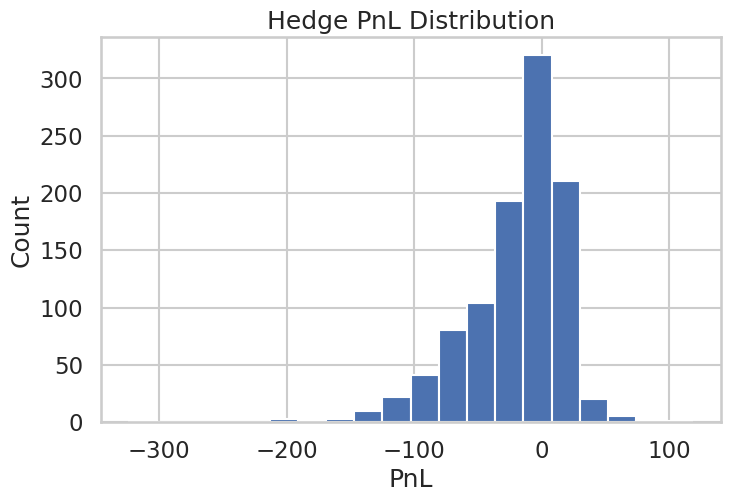

In [8]:
pnl = pd.Series(hedge["pnl_paths"])

plt.figure(figsize=(8, 5))
plt.hist(pnl, bins=20)
plt.title("Hedge PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Count")
plt.show()

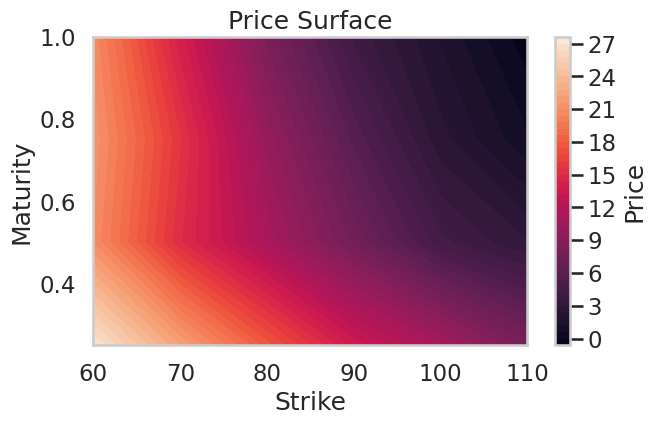

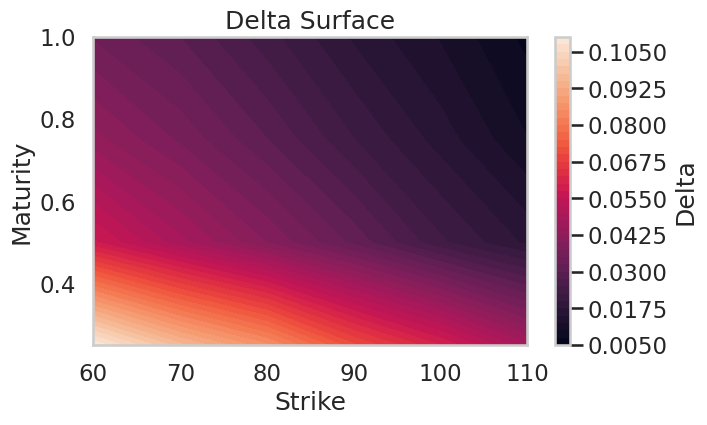

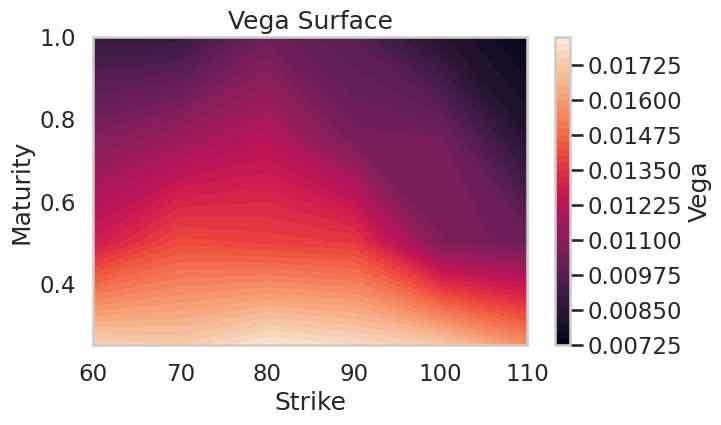

In [6]:
surface = pricer.build_greek_surface(
    strikes=[60, 70, 80, 90, 100, 110],
    maturities=[0.25, 0.50, 0.75, 1.00],
    regime="all",
    use_hourly=True,
    n_paths=2500,
    n_jobs=1,
    verbose=0,
)

pivot_price = surface.pivot(index="maturity", columns="strike", values="price")
pivot_delta = surface.pivot(index="maturity", columns="strike", values="delta")
pivot_vega  = surface.pivot(index="maturity", columns="strike", values="vega")

for title, grid, label in [
    ("Price Surface", pivot_price, "Price"),
    ("Delta Surface", pivot_delta, "Delta"),
    ("Vega Surface", pivot_vega, "Vega"),
]:
    plt.figure(figsize=(7,4))
    plt.contourf(grid.columns, grid.index, grid.values, levels=50)
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("Strike")
    plt.ylabel("Maturity")
    plt.show()